In [20]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from PIL import Image
from tqdm import tqdm

import sys
sys.path.append('../')
from solar_irradiance.datamodules.sun_mask import SunMask
from solar_irradiance.datamodules.cloud_mask import CloudMask

In [7]:
irr_df = pd.read_csv('../data/Prepared/cleaned_irradiance.csv', parse_dates=['datetime'], index_col='datetime')
irr_df.index = pd.to_datetime(irr_df.index, utc=True)

In [8]:
irr_df.head()

,Unnamed: 0,irradiance,image_name
datetime,,,
2014-01-02 15:28:00+00:00,448,4.87,20140102_072800.jpg
2014-01-02 15:29:00+00:00,449,5.59,20140102_072900.jpg
2014-01-02 15:30:00+00:00,450,1.23,20140102_073000.jpg
2014-01-02 15:31:00+00:00,451,1.62,20140102_073100.jpg
2014-01-02 15:32:00+00:00,452,2.04,20140102_073200.jpg


In [9]:
irr_df.reset_index().datetime.dt

In [10]:
irr_df.reset_index().groupby([
    irr_df.reset_index().datetime.dt.year,
    irr_df.reset_index().datetime.dt.month, 
    irr_df.reset_index().datetime.dt.day,
]).count().sort_values(by='image_name')

datetime  Unnamed: 0  irradiance  image_name
datetime datetime datetime                                              
2016     12       31              48          48          48          48
2015     12       31              48          48          48          48
2014     1        30              79          79          79          79
         2        13              95          95          95          95
         6        4              164         164         164         164
...                              ...         ...         ...         ...
2015     6        17             882         882         882         882
2014     6        17             882         882         882         882
2016     6        24             882         882         882         882
2015     6        20             883         883         883         883
                  19             883         883         883         883

[1071 rows x 4 columns]

In [11]:
image_dir = './20140620'
image_list = sorted(list(Path(image_dir).glob('*.jpg')))

In [13]:
model_path = Path('../timm-resnet50-bof-15-min.onnx')
sess = ort.InferenceSession(str(model_path), providers=['CPUExecutionProvider'])

inputs = [l.name for l in sess.get_inputs()]
shapes = [l.shape for l in sess.get_inputs()]
print(f"Model inputs: {inputs}")
print(f"Model inputs' shapes: {shapes}")

Model inputs: ['image_input', 'irradiance_history']
Model inputs' shapes: [[1, 7, 128, 128], [1, 4]]


In [14]:
def preprocess(img_data: np.ndarray) -> np.ndarray:
    mean_vec = np.array([0.485, 0.456, 0.406])
    stddev_vec = np.array([0.229, 0.224, 0.225])

    img_data = (img_data / 255 - mean_vec) / stddev_vec
    img_data = np.transpose(img_data, (2, 0, 1))

    return img_data.astype("float32")

In [31]:
MAX_IRRADIANCE = 1366.0
LATITUDE = 38.642
LONGITUDE = -121.148
CAMERA_ORIENTATION_COMPENSATION = 165
FOCAL_LENGTH = 0.48
sun_mask_gen = SunMask(LATITUDE, LONGITUDE, CAMERA_ORIENTATION_COMPENSATION, FOCAL_LENGTH)


cloud_mask_model = CloudMask(shape=(128, 128), method='normalized_blue_red_ratio')

optical_flow_model = cv2.DISOpticalFlow_create(preset=cv2.DISOPTICAL_FLOW_PRESET_FAST)

gt_irradiances = []
predicted_irradiances = []
persistent_model_irradiances = []

for image_path in tqdm(image_list[15:]):
    t = irr_df[irr_df['image_name'] == image_path.name].index
    
    t_m15 = t - pd.Timedelta(minutes=15)
    t_m10 = t - pd.Timedelta(minutes=10)
    t_m5 = t - pd.Timedelta(minutes=5)
    t_p15 = t + pd.Timedelta(minutes=15)
    
    try:
        if all(map(lambda x: not irr_df.loc[x].empty, [t_m15, t_m10, t_m5, t, t_p15])):
            flow = None
            prev_image = None

            source_irradiances = []
            source_images = []
            for _t in [t_m15, t_m10, t_m5, t]:
                row = irr_df.loc[_t]
                irradiance = row['irradiance'].values[0] #/ MAX_IRRADIANCE
                image_path = Path(image_dir, row['image_name'].values[0])
                source_image = np.asarray(Image.open(image_path))
                source_image = cv2.resize(source_image, (128, 128))
                
                input_data = preprocess(source_image)

                sun_mask = sun_mask_gen(image_shape=source_image.shape, timestamp=image_path.name[:15])
                input_data = np.concatenate([input_data, np.transpose(sun_mask * irradiance, (2, 0, 1))], axis=0)

                cloud_mask = cloud_mask_model(image=source_image)
                input_data = np.concatenate([input_data, np.transpose(cloud_mask, (2, 0, 1))], axis=0)

                image_for_flow = cv2.cvtColor(source_image, cv2.COLOR_RGB2GRAY)

                if prev_image is None:
                    prev_image = image_for_flow.copy()

                flow = optical_flow_model.calc(prev_image, image_for_flow, flow)

                prev_image = image_for_flow.copy()
                input_data = np.concatenate([input_data, np.transpose(flow, (2, 0, 1))], axis=0)

                source_irradiances.append(irradiance)
                source_images.append(input_data)
                
            # image_input = np.expand_dims(np.transpose(source_images, (1, 0, 2, 3)), axis=0).astype(np.float32)
            image_input = np.expand_dims(source_images[-1], axis=0).astype(np.float32)
            irradiance_input = np.expand_dims(source_irradiances, axis=0).astype(np.float32)
            
            predicted_irradiance = output = sess.run(None, {
                inputs[0]: image_input,
                inputs[1]: irradiance_input,
            })[0][0][0]
            predicted_irradiances.append(predicted_irradiance)

            row = irr_df.loc[t]
            irradiance = row['irradiance']
            persistent_model_irradiances.append(irradiance)

            row = irr_df.loc[t_p15]
            irradiance = row['irradiance']
            gt_irradiances.append(irradiance)
    except KeyError:
        continue

  0%|          | 0/867 [00:00<?, ?it/s]/home/mateusz/Research/solar-irradiance/notebooks/../solar_irradiance/datamodules/sun_mask.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  zenith = solarposition['zenith'][0]
/home/mateusz/Research/solar-irradiance/notebooks/../solar_irradiance/datamodules/sun_mask.py:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  azimuth = solarposition['azimuth'][0]
100%|██████████| 867/867 [03:19<00:00,  4.34it/s]


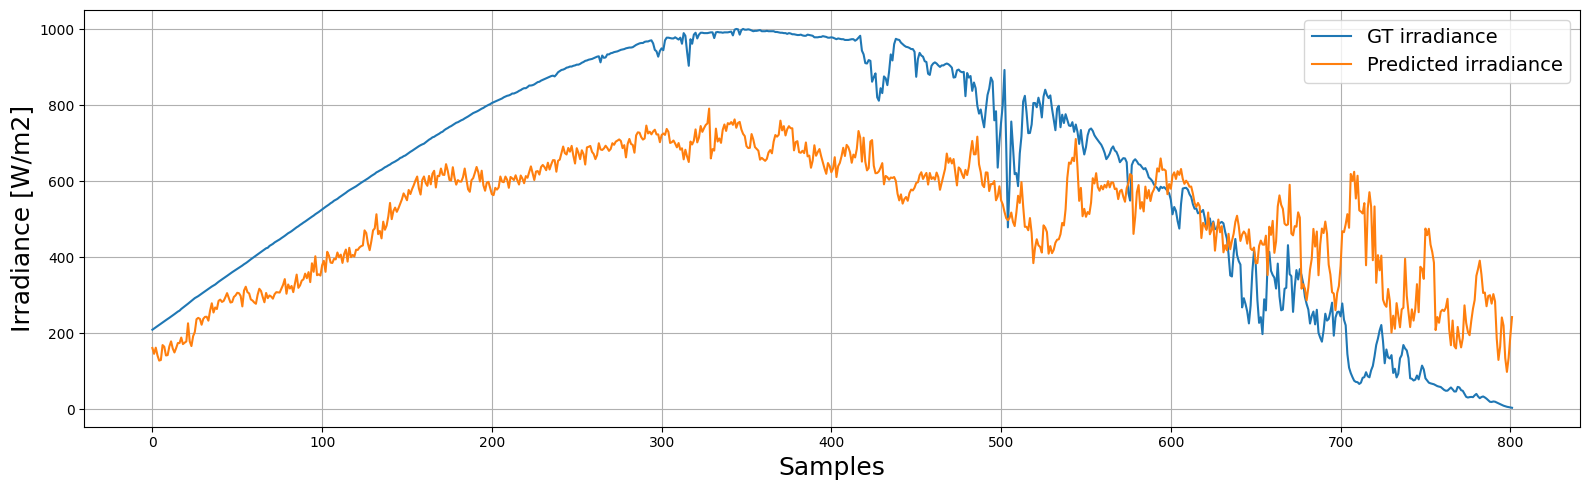

In [32]:
fig = plt.figure(figsize=(16, 5))

plt.plot(gt_irradiances[50:], label='GT irradiance')
# plt.plot(persistent_model_irradiances, label='Persistent Model')
plt.plot(predicted_irradiances[50:], label='Predicted irradiance')
plt.grid(True)
plt.legend(fontsize=14)
plt.ylabel('Irradiance [W/m2]', fontsize=18)
plt.xlabel('Samples', fontsize=18)
plt.tight_layout()
# plt.show()
# plt.savefig(f'irradiance_prediction_{image_dir}.png', dpi=300)